## Parte A: Modificações no Labirinto e Algoritmos

### 1. Preparação do Ambiente

In [116]:
import random
import time
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
import tracemalloc

def gerar_labirinto_denso(linhas, colunas, densidade_obstaculos=0.3):
    """Gera um labirinto com obstáculos aleatórios."""
    labirinto = [['.' for _ in range(colunas)] for _ in range(linhas)]
    for i in range(linhas):
        labirinto[i][0] = labirinto[i][colunas-1] = '#'
    for j in range(colunas):
        labirinto[0][j] = labirinto[linhas-1][j] = '#'
    for i in range(1, linhas - 1):
        for j in range(1, colunas - 1):
            if random.random() < densidade_obstaculos:
                labirinto[i][j] = '#'
    labirinto[1][1] = 'S'
    labirinto[linhas - 2][colunas - 2] = 'G'
    return labirinto

def exibir_visualizacao(labirinto, caminho=None, visitados=None, titulo="Busca"):
    linhas, colunas = len(labirinto), len(labirinto[0])
    res = np.zeros((linhas, colunas))
    for i in range(linhas):
        for j in range(colunas):
            if labirinto[i][j] == '#': res[i][j] = 0 # Parede
            elif labirinto[i][j] == 'S': res[i][j] = 0.5 # Início
            elif labirinto[i][j] == 'G': res[i][j] = 0.8 # Fim
            else: res[i][j] = 1 # Livre
    plt.figure(figsize=(10, 6))
    plt.imshow(res, cmap='nipy_spectral')
    if visitados:
        vx, vy = zip(*visitados)
        plt.scatter(vy, vx, color='yellow', s=10, label='Visitados', alpha=0.3)
    if caminho:
        cx, cy = zip(*caminho)
        plt.plot(cy, cx, color='red', linewidth=2, label='Caminho')
    plt.title(titulo)
    plt.legend()
    plt.show()

### 2. Implementação com Movimentos Diagonais

Adicionamos a lógica para permitir 8 direções de movimento.

In [117]:
def get_direcoes(diagonal=True):
    direcoes = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if diagonal:
        direcoes += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    return direcoes

def bfs(labirinto, diagonal=True):
    linhas, colunas = len(labirinto), len(labirinto[0])
    inicio, objetivo = (1, 1), (linhas - 2, colunas - 2)
    fila = deque([(inicio, [inicio])])
    visitados = {inicio}
    direcoes = get_direcoes(diagonal)
    start_time = time.perf_counter()
    while fila:
        (x, y), caminho = fila.popleft()
        if (x, y) == objetivo:
            return caminho, visitados, time.perf_counter() - start_time
        for dx, dy in direcoes:
            nx, ny = x + dx, y + dy
            if 0 <= nx < linhas and 0 <= ny < colunas and labirinto[nx][ny] != '#' and (nx, ny) not in visitados:
                visitados.add((nx, ny))
                fila.append(((nx, ny), caminho + [(nx, ny)]))
    return None, visitados, time.perf_counter() - start_time

def dfs(labirinto, diagonal=True):
    linhas, colunas = len(labirinto), len(labirinto[0])
    inicio, objetivo = (1, 1), (linhas - 2, colunas - 2)
    pilha = [(inicio, [inicio])]
    visitados = {inicio}
    direcoes = get_direcoes(diagonal)
    start_time = time.perf_counter()
    while pilha:
        (x, y), caminho = pilha.pop()
        if (x, y) == objetivo:
            return caminho, visitados, time.perf_counter() - start_time
        for dx, dy in reversed(direcoes):
            nx, ny = x + dx, y + dy
            if 0 <= nx < linhas and 0 <= ny < colunas and labirinto[nx][ny] != '#' and (nx, ny) not in visitados:
                visitados.add((nx, ny))
                pilha.append(((nx, ny), caminho + [(nx, ny)]))
    return None, visitados, time.perf_counter() - start_time

## Parte B: Proposta de Análise Big(O)

### 3. Comparação BFS vs DFS

--- Executando BFS ---
BFS: 40 passos, 735 visitados, Tempo: 0.0062s


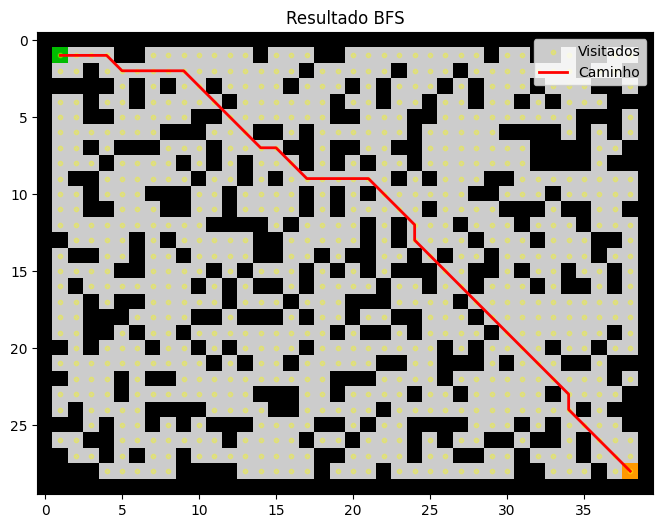

Uso de memória: 0.928247 MB
Uso máximo de memória: 12.586164 MB

--- Executando DFS ---
DFS: 198 passos, 675 visitados, Tempo: 0.0148s


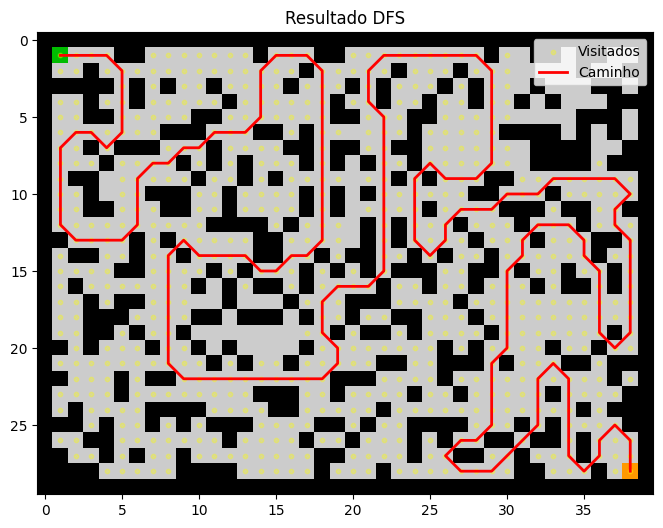

Uso de memória: 0.968631 MB
Uso máximo de memória: 12.613115 MB


In [119]:
lab = gerar_labirinto_denso(30, 40, 0.3)

print("--- Executando BFS ---")
tracemalloc.start()
c_bfs, v_bfs, t_bfs = bfs(lab, True)
if c_bfs:
    print(f"BFS: {len(c_bfs)} passos, {len(v_bfs)} visitados, Tempo: {t_bfs:.4f}s")
    exibir_visualizacao(lab, c_bfs, v_bfs, "Resultado BFS")
else:
    print("Nenhuma solução encontrada.")

current, peak = tracemalloc.get_traced_memory()
print(f"Uso de memória: {current / 10**6} MB")
print(f"Uso máximo de memória: {peak / 10**6} MB")
tracemalloc.stop()

print("\n--- Executando DFS ---")
tracemalloc.start()
c_dfs, v_dfs, t_dfs = dfs(lab, True)
if c_dfs:
    print(f"DFS: {len(c_dfs)} passos, {len(v_dfs)} visitados, Tempo: {t_dfs:.4f}s")
    exibir_visualizacao(lab, c_dfs, v_dfs, "Resultado DFS")
else:
    print("Nenhuma solução encontrada.")

current, peak = tracemalloc.get_traced_memory()
print(f"Uso de memória: {current / 10**6} MB")
print(f"Uso máximo de memória: {peak / 10**6} MB")
tracemalloc.stop()